# Solutions · 12 · Partial differential equations: heat penetration and diffusion

Worked solutions to the exercises of [notebook 12](../notebooks/12_diffusion_pde.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import datasets, optimize, pdes, linalg
from scipy.special import erf, erfc
alpha, T0, Ts = 1.2e-5, 20.0, 320.0
tc = np.loadtxt(datasets.path("thermocouple_10mm.csv"), delimiter=",", skiprows=1)
t_meas, T_meas = tc[:, 0], tc[:, 1]
def fit_alpha(x_tc):
    rss = lambda la: np.sum((Ts + (T0 - Ts)*erf(x_tc/(2*np.sqrt(10**la*t_meas))) - T_meas)**2)
    return 10**optimize.golden_section(rss, -6, -4).x[0]

## Exercise 1

Repeat the inverse problem with the thermocouple position uncertain by ±0.5 mm. How does that
   uncertainty propagate into $\alpha$? (Hint: $\alpha$ enters only through $x/\sqrt{\alpha t}$.)

In [2]:
a_nom = fit_alpha(0.010)
for x_tc in (0.0095, 0.0105):
    a = fit_alpha(x_tc)
    print(f"thermocouple at {x_tc*1000:.1f} mm: alpha = {a*1e6:.2f} mm²/s ({(a/a_nom - 1)*100:+.1f} %)")
print(f"nominal 10.0 mm: alpha = {a_nom*1e6:.2f} mm²/s; statistical standard error about 0.05 mm²/s (notebook 12)")

thermocouple at 9.5 mm: alpha = 10.81 mm²/s (-9.8 %)
thermocouple at 10.5 mm: alpha = 13.20 mm²/s (+10.3 %)
nominal 10.0 mm: alpha = 11.97 mm²/s; statistical standard error about 0.05 mm²/s (notebook 12)


The data only determine the combination $x/\sqrt{\alpha t}$, so $\alpha \propto x^2$ and a 5 % position error
becomes a 10 % error in $\alpha$ - twenty times the statistical uncertainty from the temperature noise. The
thermocouple position dominates the uncertainty budget. A better experiment measures the position
precisely (e.g. by X-ray) or uses two thermocouples, so that only their *distance* matters.

## Exercise 2

Replace the fixed surface temperature by convection (a Robin boundary condition) in the
   Crank-Nicolson scheme: which entries of the tridiagonal system change?

In [3]:
L, nx = 0.25, 501
x = np.linspace(0, L, nx); dx = x[1] - x[0]
h, k = 500.0, 45.0                                      # W/(m2 K), W/(m K): hot gas on a steel surface
T_gas = Ts
def cn_convective(t_end, dt):
    r = alpha * dt / dx**2
    Bi = 2 * dx * h / k                                  # ghost node: T_-1 = T_1 + (2 dx h/k)(T_gas - T_0)
    n = nx - 1                                           # unknowns T_0 ... T_{nx-2}; far end fixed at T0
    lower, diag, upper = np.full(n, -r/2), np.full(n, 1 + r), np.full(n, -r/2)
    diag[0] = 1 + r + r/2*Bi; upper[0] = -r              # first row: the only entries that change
    T = np.full(nx, T0)
    for _ in range(int(round(t_end/dt))):
        rhs = r/2*np.r_[T[1], T[:-2]] + (1 - r)*T[:-1] + r/2*T[1:]
        rhs[0] = (1 - r - r/2*Bi)*T[0] + r*T[1] + r*Bi*T_gas
        rhs[-1] += r/2*T0
        T[:-1] = linalg.thomas(lower, diag, upper, rhs)
    return T
def exact_conv(x, t):                                   # semi-infinite solid with surface convection
    s = np.sqrt(alpha*t)
    theta = erfc(x/(2*s)) - np.exp(h*x/k + h**2*alpha*t/k**2) * erfc(x/(2*s) + h*s/k)
    return T0 + (T_gas - T0) * theta
T60 = cn_convective(60.0, 0.05)
print(f"surface temperature after 60 s: CN {T60[0]:.3f} °C, exact {exact_conv(0.0, 60.0):.3f} °C; "
      f"max error {np.max(np.abs(T60 - exact_conv(x, 60.0))):.3f} K")

surface temperature after 60 s: CN 99.236 °C, exact 99.236 °C; max error 0.001 K


With convection $-k\,\partial T/\partial x = h(T_{gas} - T)$ at the surface, the surface temperature becomes an
unknown. A ghost node eliminates the derivative, and only the **first row** changes - its diagonal and
upper entries, and a new term $r\,Bi\,T_{gas}$ on the right-hand side - so the system stays tridiagonal. The
result agrees with the classical analytical solution for a semi-infinite solid with surface convection.

## Exercise 3

For mass transfer into a polymer film, the uptake per unit area is
   $M_t = 2C_s\sqrt{Dt/\pi}$ at early times. Show that fitting $M_t$ against $\sqrt t$ is a *linear*
   regression, and use it to estimate $D$ from simulated data with 3 % noise.

D = 1.012e-12 ± 1.3e-14 m²/s  (true 1.0e-12)


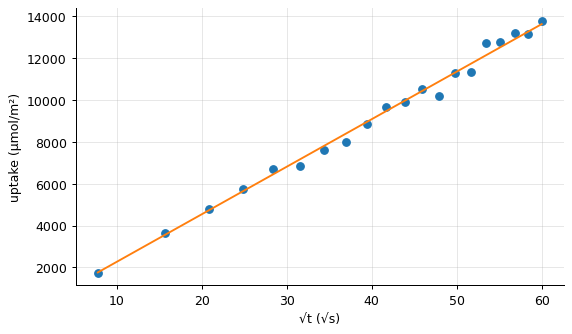

In [4]:
from engmath import fitting
Cs, D_true = 200.0, 1.0e-12                         # mol/m3, m2/s
t = np.linspace(60, 3600, 20)
rng = np.random.default_rng(12)
M = 2*Cs*np.sqrt(D_true*t/np.pi) * (1 + 0.03*rng.standard_normal(t.size))
f = fitting.linear_lstsq(np.sqrt(t)[:, None], M)       # M = slope * sqrt(t): a line through the origin
slope, se = f.coef[0], f.se[0]
D_est = np.pi * (slope/(2*Cs))**2
print(f"D = {D_est:.3e} ± {2*se/slope*D_est:.1e} m²/s  (true {D_true:.1e})")
plt.plot(np.sqrt(t), M*1e6, "o"); plt.plot(np.sqrt(t), slope*np.sqrt(t)*1e6)
plt.xlabel("√t (√s)"); plt.ylabel("uptake (µmol/m²)"); plt.show()

$M_t = \left(2C_s\sqrt{D/\pi}\right)\sqrt t$ is a straight line through the origin in $\sqrt t$, so ordinary linear least
squares gives the slope, and $D = \pi\,(\text{slope}/2C_s)^2$. Because $D$ depends on the *square* of the slope,
its relative uncertainty is twice that of the slope. The early-time formula only holds while the
penetration depth is small compared with the film thickness; later points bend away from the line.

## Exercise 4

**Implement it yourself:** implicit (backward) Euler for the heat equation solves $(1 + 2r)T_i^{n+1} - rT_{i-1}^{n+1} - rT_{i+1}^{n+1} = T_i^n$ - one Thomas solve per step. Show that it is stable at $r = 100$ and compare its early-time error with Crank-Nicolson.

In [5]:
L2, nx2 = 0.25, 501
x2 = np.linspace(0, L2, nx2); dx2 = x2[1] - x2[0]
exact = lambda x, t: Ts + (T0 - Ts)*erf(x/(2*np.sqrt(alpha*t)))
def implicit_euler(t_end, r):
    dt = r*dx2**2/alpha; n = nx2 - 2
    lower, diag, upper = np.full(n, -r), np.full(n, 1 + 2*r), np.full(n, -r)
    T = np.full(nx2, T0); T[0] = Ts
    for _ in range(max(1, int(round(t_end/dt)))):
        rhs = T[1:-1].copy(); rhs[0] += r*Ts; rhs[-1] += r*T0
        T[1:-1] = linalg.thomas(lower, diag, upper, rhs)
    return T
for t_end in (1.0, 60.0):
    for r in (10.0, 100.0):
        n_steps = max(1, int(round(t_end/(r*dx2**2/alpha))))
        dt = t_end / n_steps
        e_ie = np.max(np.abs(implicit_euler(t_end, r) - exact(x2, t_end)))
        e_cn = np.max(np.abs(pdes.crank_nicolson(np.full(nx2, T0), alpha, dx2, dt, n_steps, Ts, T0) - exact(x2, t_end)))
        print(f"t = {t_end:4.0f} s, r = {r:5.0f}: implicit Euler error {e_ie:7.3f} K, Crank-Nicolson {e_cn:7.3f} K")

t =    1 s, r =    10: implicit Euler error   5.688 K, Crank-Nicolson  42.835 K
t =    1 s, r =   100: implicit Euler error  30.025 K, Crank-Nicolson 213.777 K


t =   60 s, r =    10: implicit Euler error   0.144 K, Crank-Nicolson   0.001 K
t =   60 s, r =   100: implicit Euler error   0.971 K, Crank-Nicolson  74.729 K


Implicit Euler is stable for any $r$, like Crank-Nicolson. At early times with large steps it is the more
accurate of the two here: it strongly damps the short-wavelength components excited by the sudden
surface jump, which Crank-Nicolson lets oscillate. At later times, with a moderate step ($r$ = 10),
Crank-Nicolson's second-order accuracy in time wins clearly - but with $r$ = 100 its oscillations have still
not died out after 60 s. Practical codes therefore often start with a few implicit Euler steps (or small
steps) and then switch to Crank-Nicolson.